In [2]:
import pandas as pd
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import stumpy

In [3]:
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI    = "http://example.com/Gent-Terneuzen"
USERNAME     = "dba"
PASSWORD     = "dba"
AUTH         = (USERNAME, PASSWORD)

In [4]:
params  = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors


In [5]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT DISTINCT ?sensor
    WHERE {{
        GRAPH <{GRAPH_URI}> {{
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }}
    }}
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
    print(f"Error: {res.status_code}")
    print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data     = res.json()
bindings = data['results']['bindings']
for row in bindings:
    sensor_set.add(row['sensor']['value'])

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)

Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289429042'}


# Reframe the data

In [6]:
final_df = pd.DataFrame()
print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    column_name = sensor_uri.split('/')[-1]
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{
            GRAPH <{GRAPH_URI}> {{
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }}
        }}
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']),
             'unixtime': int(row['unixtime']['value'])}
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            if final_df.empty:
                final_df = temp_df
            else:
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')
            print(f"Added column for sensor: {column_name}")

final_df = final_df.sort_values('time').set_index('time')
print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289423042
Added column for sensor: 289435042
Added column for sensor: 289441042
Added column for sensor: 289429042
Finished!
                           289423042    unixtime  289435042  289441042  \
time                                                                     
2021-03-03 23:15:00+00:00        NaN  1614813300    3606.54    4797.72   
2021-03-03 23:30:00+00:00        NaN  1614814200        NaN    4717.80   
2021-03-03 23:45:00+00:00     902.27  1614815100    3556.45    4745.36   
2021-03-04 00:00:00+00:00        NaN  1614816000        NaN        NaN   
2021-03-04 00:15:00+00:00     901.96  1614816900        NaN        NaN   

                           289429042  
time                                  
2021-03-03 23:15:00+00:00    1605.77  
2021-03-03 23:30:00+00:00        NaN  
2021-03-03 23:45:00+00:00    1602.34  
2021-03-04 00:00:00+00:00    1611.26  
2021-03-04 00:15:00+00:00    1614.24  


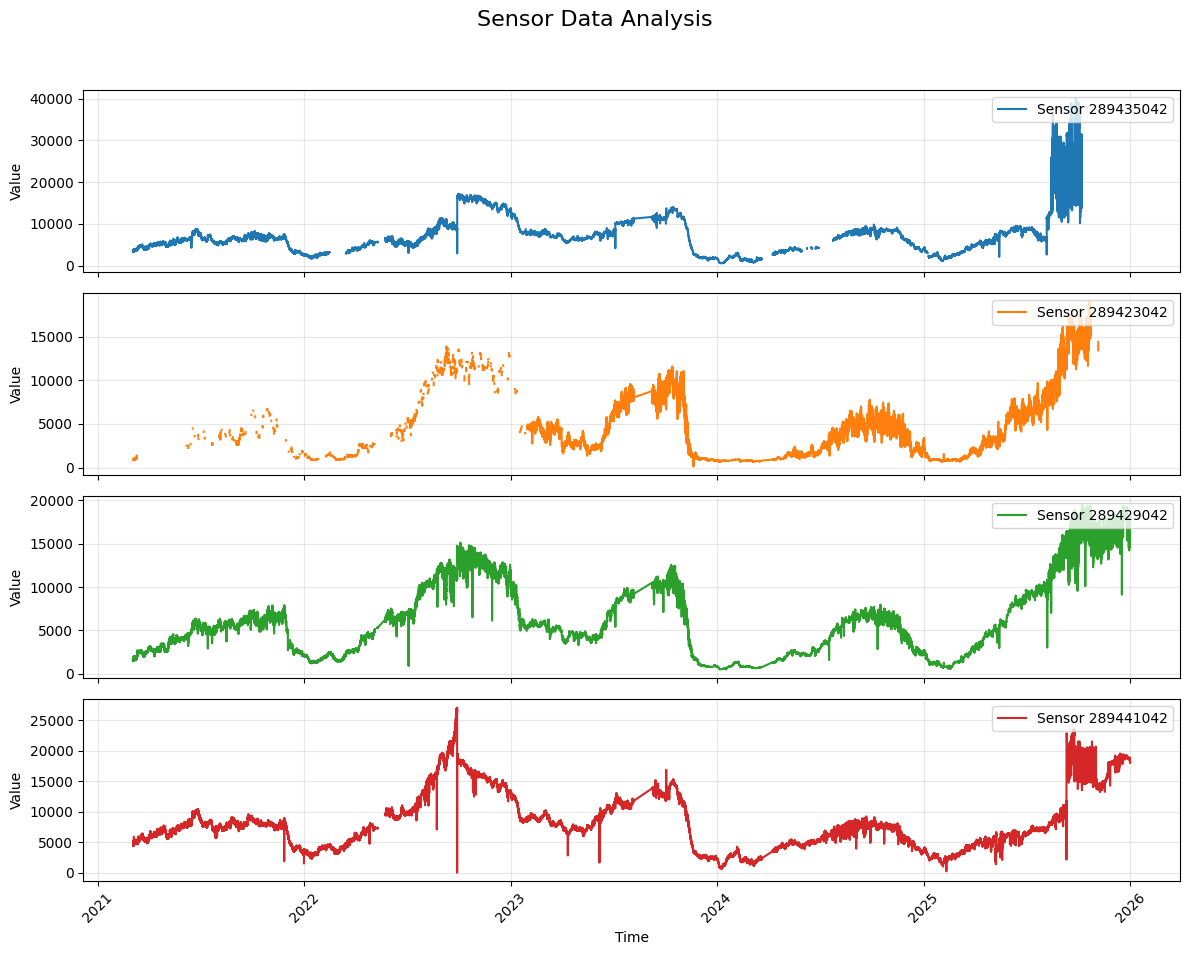

In [7]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, sensor in enumerate(sensors):
    ax = axes[i]
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Feature Engineering

In [8]:
data = final_df.copy()
target_sensor = '289441042'

# 1. Time-based features (Seasonality)
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek
data['month'] = data.index.month


# 2. Lag features for the TARGET (Sensor 4)
    # We look back 15m, 1h, and 24h
for lag in [1, 4, 96,672, 2880]:
    data[f'{target_sensor}_lag_{lag}'] = data[target_sensor].shift(lag)

# 3. Spatial Lag features for NEIGHBORS (Sensors 1, 2, 3)
# These provide "upstream" context
neighbors = [c for c in final_df.columns if c != target_sensor]

for s in neighbors:
        data[f'{s}_lag_1'] = data[s].shift(1)  # What happened 15 mins ago upstream?
        data[f'{s}_lag_4'] = data[s].shift(4)  # What happened 1 hour ago upstream?
        data[f'{s}_lag_672']  = data[s].shift(672)   # 1 week ago upstream
        data[f'{s}_lag_2880'] = data[s].shift(2880)
        data[f'{s}_roc_1']  = data[s].diff(1)   # upstream rate of change
        data[f'{s}_roc_4']  = data[s].diff(4)   # upstream hourly change
        data[f'{s}_roc_672']  = data[s].diff(672)   # upstream weekly change
        data[f'{s}_roc_2880'] = data[s].diff(2880)  # upstream monthly change

# 4. Rolling statistics (Trend)
data['rolling_mean_6h'] = data[target_sensor].shift(1).rolling(window=24).mean()

# In Cell 9, after rolling_mean_6h:

# Rate of change (is the signal rising or falling fast?)
data['roc_1']  = data[target_sensor].diff(1)   # 15-min change
data['roc_4']  = data[target_sensor].diff(4)   # 1-hour change
data['roc_96'] = data[target_sensor].diff(96)  # 24-hour change

# Volatility (is the signal stable or jumping around?)
data['rolling_std_6h']  = data[target_sensor].shift(1).rolling(window=24).std()
data['rolling_std_24h'] = data[target_sensor].shift(1).rolling(window=96).std()

# Rolling min/max (captures the range of recent behaviour)
data['rolling_max_24h'] = data[target_sensor].shift(1).rolling(window=96).max()
data['rolling_min_24h'] = data[target_sensor].shift(1).rolling(window=96).min()


data.dropna(inplace=True)
df_featured = data.copy()
print(f"df_featured shape: {df_featured.shape}")
print(f"Date range: {df_featured.index.min()} → {df_featured.index.max()}")

df_featured shape: (75402, 53)
Date range: 2023-02-06 14:00:00+00:00 → 2025-10-07 07:30:00+00:00


# Data preparation

In [9]:
# Split based on your specific dates
train_data = df_featured[:'2025-07-31'] # all data up to July 2025
test_data = df_featured['2025-07-01':'2025-07-30'] # ground truth month



X_train = train_data.drop(columns=sensors)  # Drop original sensor columns
y_train = train_data[target_sensor]

X_test = test_data.drop(columns=sensors)
y_test = test_data[target_sensor]

# Does the data contain high conductivity events? 
print("Train conductivity range:", y_train.min(), "→", y_train.max())
print("Test  conductivity range:", y_test.min(),  "→", y_test.max())

Train conductivity range: 226.79 → 16851.66
Test  conductivity range: 6074.92 → 7693.67


In [10]:
# Sanity check
# #print("Training data shape:", X_train.shape)
# print("Testing data shape:", X_test.shape)
# #print(X_train.head())
# print(X_test.head())



# Actual training 

In [11]:
model = lgb.LGBMRegressor(
    n_estimators=5000,      # Increased: More trees for better learning
    learning_rate=0.01,     # Decreased: Slower, more precise learning
    num_leaves=128,         # Increased: Allows for more complex patterns
    max_depth=12,           # Limited: Prevents the trees from growing too deep
    min_data_in_leaf=50,   # Regularization: Prevents overfitting to noise (lower = more sensitive)
    feature_fraction=0.8,   # Generalization: Don't rely on all sensors at once
    n_jobs=-1,
    subsample=0.8,          # ADD: row subsampling for better generalisation
    reg_alpha=0.1,          # ADD: L1 regularisation
    reg_lambda=0.1,         # ADD: L2 regularisation
)

# Use early stopping to find the perfect n_estimators automatically
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=100)] 
)

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006764 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10783
[LightGBM] [Info] Number of data points in the train set: 69041, number of used features: 47
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current 

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,12
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Forecast and Compare

In [12]:
forecast = model.predict(X_test)
mae = mean_absolute_error(y_test, forecast)
print(f"September 2025 Forecast MAE: {mae:.4f} units of conductivity")

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
September 2025 Forecast MAE: 7.2644 units of conductivity


# Bias check

In [13]:
error = y_test - forecast
print(f"Mean Error (Bias): {error.mean()}")

# positive bias means we are underpredicting on average, negative bias means we are overpredicting on average.

Mean Error (Bias): 0.06057593035504122


# Visualizing truth vs prediction

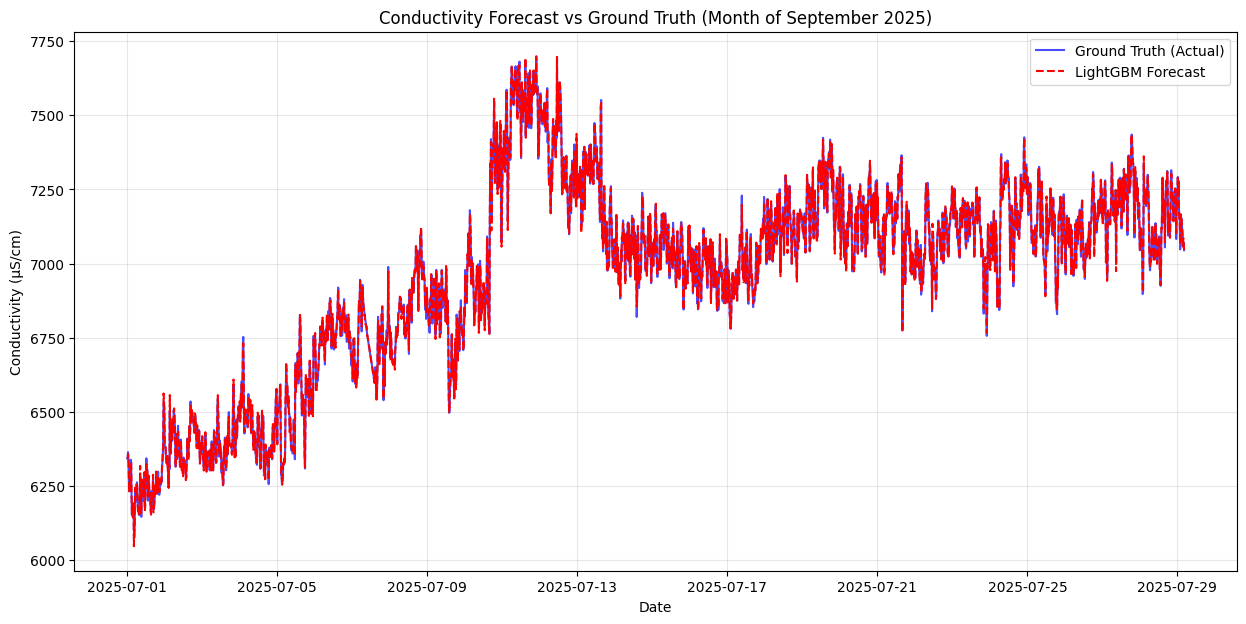

In [14]:
# 1. Create a DataFrame for easy plotting
results = pd.DataFrame({
    'Actual': y_test,
    'Forecast': forecast
}, index=y_test.index)

# 2. Plotting a 7-day window to see the detail
plt.figure(figsize=(15, 7))
plt.plot(results['Actual'].iloc[:2688], label='Ground Truth (Actual)', color='blue', alpha=0.7)
# 672 rows = 7 days * 24 hours * 4 readings/hour
plt.plot(results['Forecast'].iloc[:2688], label='LightGBM Forecast', color='red', linestyle='--')

plt.title('Conductivity Forecast vs Ground Truth (Month of September 2025)')
plt.xlabel('Date')
plt.ylabel('Conductivity (μS/cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## The model is really good in predicting a week in the future. Any more than that and it falls of quite quickly

# XGBoost

In [15]:
# 1. Convert your data into XGBoost's optimized format (DMatrix)
# Note: You use the same X_train, y_train we created for LightGBM
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [16]:
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'eta': 0.01,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'colsample_bylevel': 0.8,       # ADD: also subsample per tree depth level
    'min_child_weight': 10,         # ADD: min sum of instance weight in a leaf (like min_data_in_leaf in LightGBM)
    'gamma': 0.1,                   # ADD: min loss reduction required to split (0 = no constraint)
    'alpha': 0.1,                   # ADD: L1 regularisation on weights
    'lambda': 1.5,                  # ADD: L2 regularisation on weights (default is 1)
    'eval_metric': ['rmse', 'mae'], # CHANGE: watch both so you can see error shape
    'seed': 42,                     # ADD: reproducibility
}

evallist = [(dtrain, 'train'), (dtest, 'eval')]

# ADD: verbose_eval so you only print every 100 rounds instead of every round
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=5000,           # CHANGE: give it more headroom, early stopping will cut it short
    evals=evallist,
    early_stopping_rounds=100,      # CHANGE: 50 is too aggressive at lr=0.01, use 100
    verbose_eval=100,               # ADD: only log every 100 rounds
)

print(f"Best iteration : {bst.best_iteration}")
print(f"Best eval MAE  : {bst.best_score:.4f}")

predictions_xgb = bst.predict(dtest, iteration_range=(0, bst.best_iteration)) # XGBoost doesn't automatically use best_iteration on predict. Without this, it uses ALL trees including the ones after the best checkpoint.

[0]	train-rmse:3321.74646	train-mae:2711.50956	eval-rmse:802.65935	eval-mae:737.45716
[100]	train-rmse:1222.50750	train-mae:997.50459	eval-rmse:298.86078	eval-mae:271.50367
[200]	train-rmse:454.41127	train-mae:369.46649	eval-rmse:117.08460	eval-mae:102.57452
[300]	train-rmse:175.38155	train-mae:139.08788	eval-rmse:51.99521	eval-mae:43.61531
[400]	train-rmse:77.28876	train-mae:54.88789	eval-rmse:27.64063	eval-mae:22.21293
[500]	train-rmse:46.02019	train-mae:25.90575	eval-rmse:18.99154	eval-mae:14.62573
[600]	train-rmse:36.60622	train-mae:17.67430	eval-rmse:15.74300	eval-mae:11.83762
[700]	train-rmse:32.80529	train-mae:15.53945	eval-rmse:14.42830	eval-mae:10.74440
[800]	train-rmse:30.32377	train-mae:14.75654	eval-rmse:13.82840	eval-mae:10.26604
[900]	train-rmse:28.39531	train-mae:14.32649	eval-rmse:13.44205	eval-mae:10.02691
[1000]	train-rmse:26.94004	train-mae:14.03959	eval-rmse:13.20607	eval-mae:9.91076
[1100]	train-rmse:25.78628	train-mae:13.81417	eval-rmse:13.02970	eval-mae:9.81660
[

# Compare

In [17]:
mae_xgb = mean_absolute_error(y_test, predictions_xgb)
print(f"XGBoost  MAE: {mae_xgb:.4f}")

XGBoost  MAE: 7.5700


# Visualization

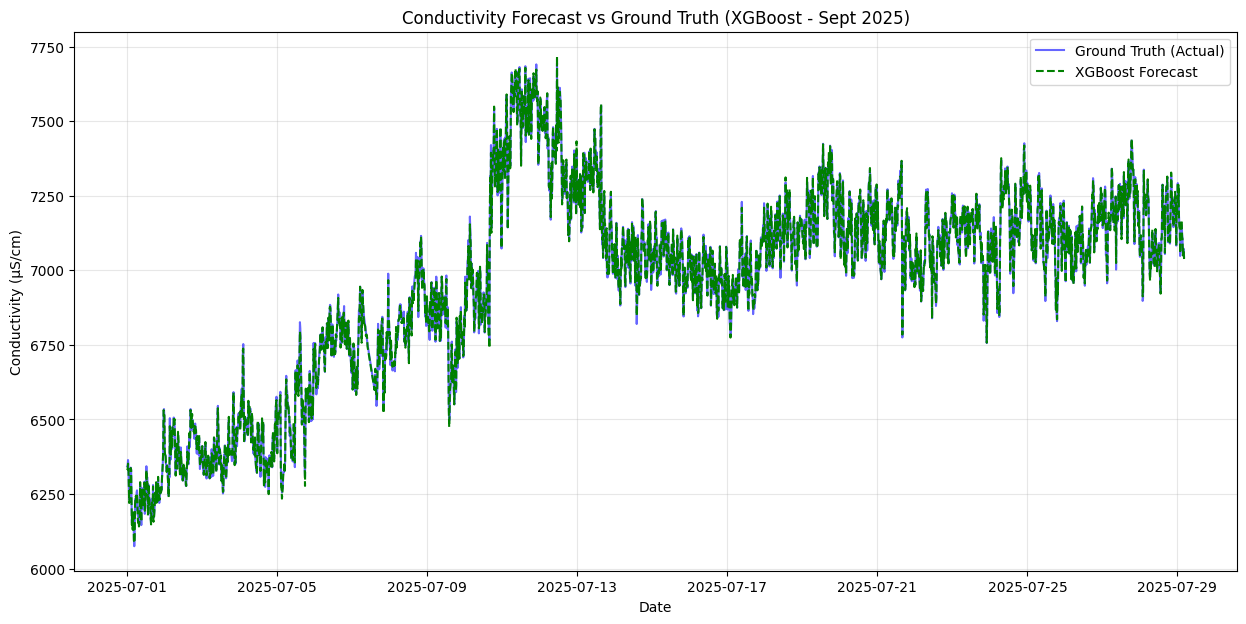

In [18]:

# 1. Create a DataFrame for XGBoost results
# Ensure 'predictions_xgb' is the output from bst.predict(dtest)
results_xgb = pd.DataFrame({
    'Actual': y_test,
    'XGBoost_Forecast': predictions_xgb
}, index=y_test.index)

# 2. Plotting the 28-day window (2688 rows)
plt.figure(figsize=(15, 7))

# Plot Actual Data
plt.plot(results_xgb['Actual'].iloc[:2688], 
         label='Ground Truth (Actual)', 
         color='blue', 
         alpha=0.6)

# Plot XGBoost Forecast
plt.plot(results_xgb['XGBoost_Forecast'].iloc[:2688], 
         label='XGBoost Forecast', 
         color='green',           # Using Green to distinguish from LightGBM's Red
         linestyle='--', 
         linewidth=1.5)

plt.title('Conductivity Forecast vs Ground Truth (XGBoost - Sept 2025)')
plt.xlabel('Date')
plt.ylabel('Conductivity (μS/cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Head to head comparison of forecasts

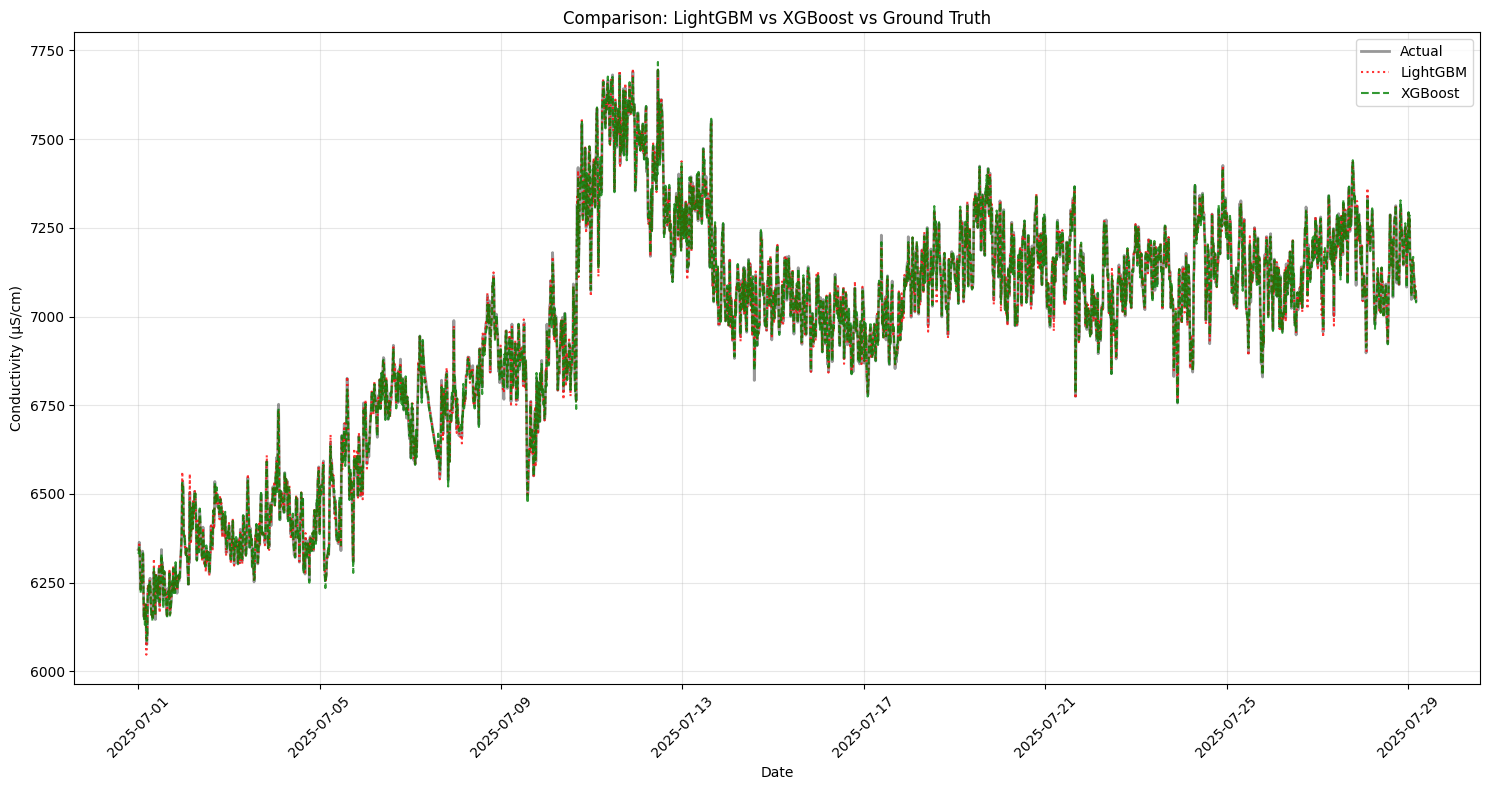

In [19]:
# Head to head comparison
comparison = pd.DataFrame({
    'Actual':   y_test.values[:2688],
    'LightGBM': forecast[:2688],
    'XGBoost':  predictions_xgb[:2688]
}, index=y_test.index[:2688])

plt.figure(figsize=(15, 8))
plt.plot(comparison['Actual'],   label='Actual',    color='black', alpha=0.4, linewidth=2)
plt.plot(comparison['LightGBM'], label='LightGBM',  color='red',   linestyle=':',  alpha=0.8)
plt.plot(comparison['XGBoost'],  label='XGBoost',   color='green', linestyle='--', alpha=0.8)

plt.title('Comparison: LightGBM vs XGBoost vs Ground Truth')
plt.xlabel('Date')
plt.ylabel('Conductivity (μS/cm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ensemble

In [20]:
final_ensemble = (forecast + predictions_xgb) / 2

mae_ensemble = mean_absolute_error(y_test, final_ensemble)
print(f"Final Ensemble MAE: {mae_ensemble:.4f}")

Final Ensemble MAE: 5.4145


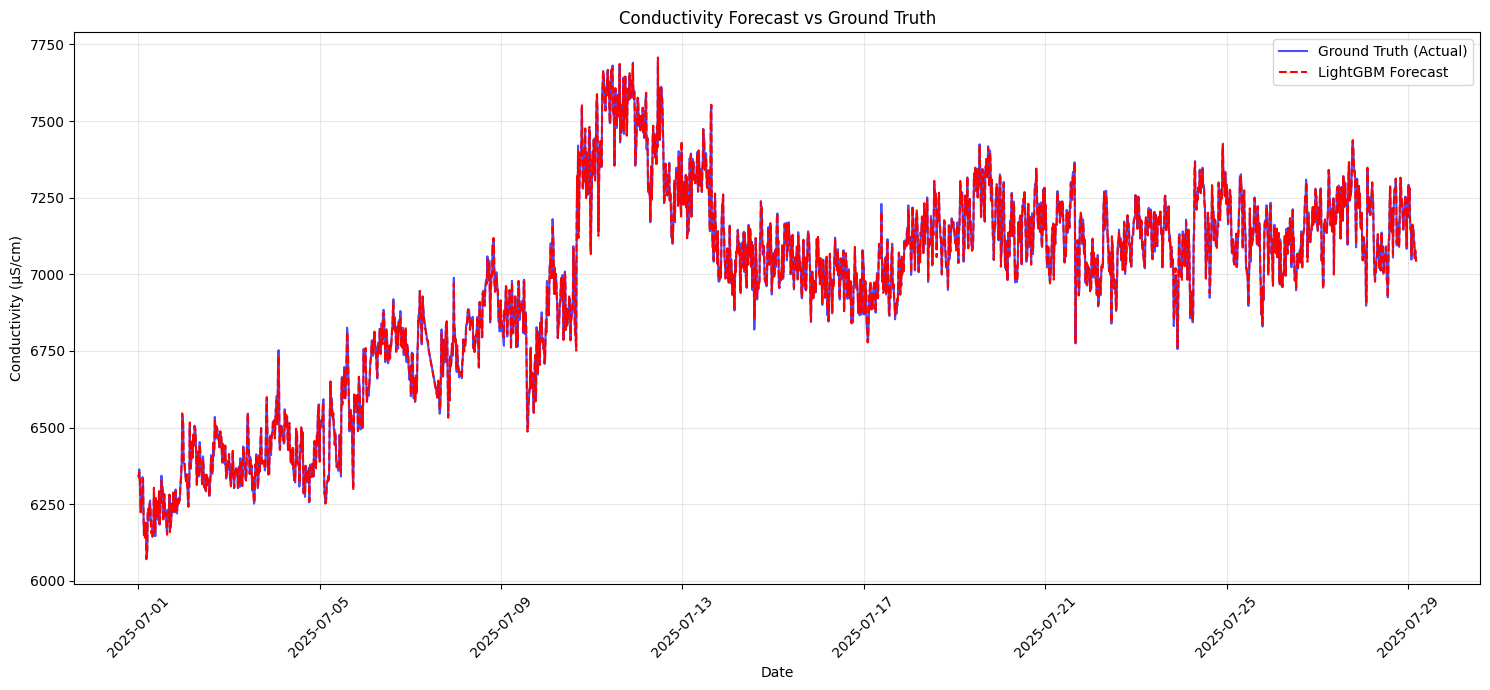

In [21]:
results = pd.DataFrame({
    'Actual':   y_test.values[:2688],
    'Forecast': final_ensemble[:2688]
}, index=y_test.index[:2688])

plt.figure(figsize=(15, 7))
plt.plot(results['Actual'],   label='Ground Truth (Actual)', color='blue', alpha=0.7)
plt.plot(results['Forecast'], label='LightGBM Forecast',     color='red',  linestyle='--')

plt.title('Conductivity Forecast vs Ground Truth')
plt.xlabel('Date')
plt.ylabel('Conductivity (μS/cm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Matrix profile

In [ ]:
# STUMPY doesn't handle NaNs, so we interpolate missing values
signal = final_df[target_sensor].interpolate(method='linear').bfill().ffill().values
# 96 periods * 15 mins = 24 hours.
m = 2880
# Compute the matrix profile
mp = stumpy.stump(signal, m)
#Find the Motif (most repeated pattern) and Discord (biggest anomaly)
motif_idx = np.argsort(mp[:, 0])[0]
discord_idx = np.argsort(mp[:, 0])[-1]

C:\Users\AYMANS\AppData\Local\Temp\ipykernel_44844\893591161.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


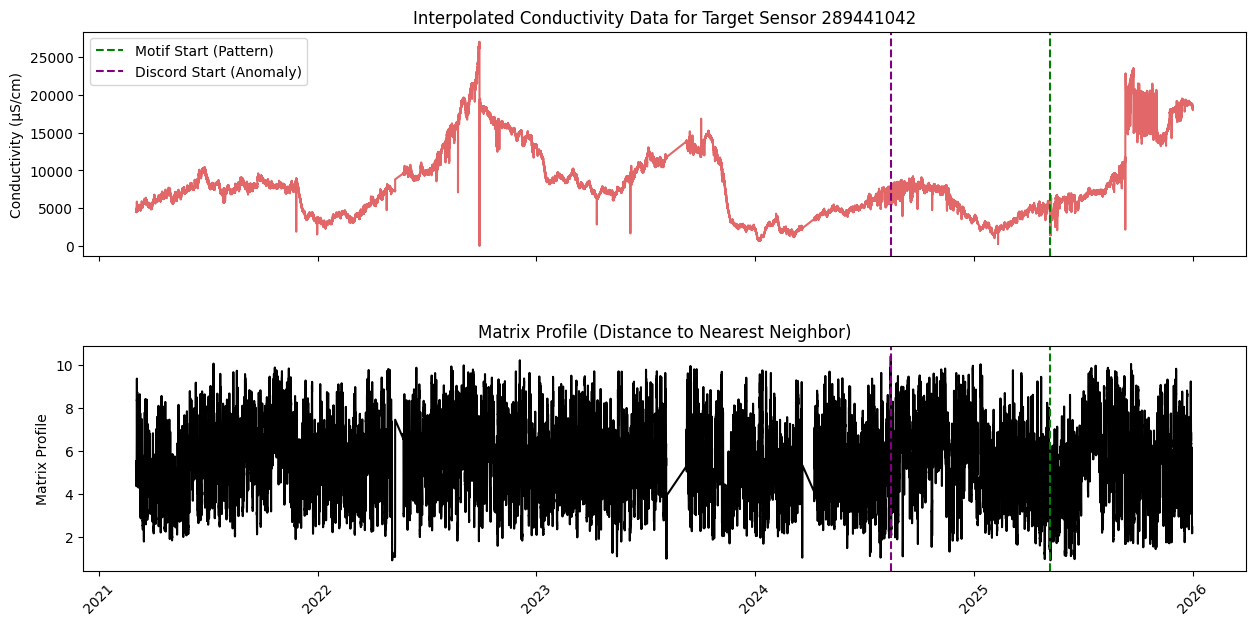

In [24]:
# Visualization
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0.4}, figsize=(15, 7))

axs[0].plot(final_df.index, signal, color='#d62728', alpha=0.7) # Using your notebook's color scheme
axs[0].set_title(f'Interpolated Conductivity Data for Target Sensor {target_sensor}')
axs[0].set_ylabel('Conductivity (μS/cm)')
# Add vertical lines at the timestamps corresponding to the indices
axs[0].axvline(x=final_df.index[motif_idx], color='green', label='Motif Start (Pattern)', linestyle='--')
axs[0].axvline(x=final_df.index[discord_idx], color='purple', label='Discord Start (Anomaly)', linestyle='--')
axs[0].legend()

axs[1].plot(final_df.index[:len(mp)], mp[:, 0], color='black')
axs[1].set_title('Matrix Profile (Distance to Nearest Neighbor)')
axs[1].set_ylabel('Matrix Profile')
axs[1].axvline(x=final_df.index[motif_idx], color='green', linestyle='--')
axs[1].axvline(x=final_df.index[discord_idx], color='purple', linestyle='--')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()